# Sicurre — CamemBERTav2 Training
**Dataset sources required on Kaggle:**
- `sicurre-ml-src` — versioned copy of `src/` from this repo (uploaded by CI)
- `sicurre-data` — frozen training CSV splits (synced from Cloudflare R2) 

In [1]:
# ── Cell 0: Environment setup ─────────────────────────────────────────
import importlib.util
import subprocess, sys, os
from pathlib import Path

# 0a. Detect accelerator FIRST — determines which fixes are needed.
_on_tpu = importlib.util.find_spec("torch_xla") is not None
print(f"[setup] Accelerator : {'TPU (torch_xla present)' if _on_tpu else 'GPU / CPU'}")

# 0b. TPU-only: fix the tensorflow / torch_xla conflict.
#     On GPU kernels tensorflow is not installed alongside XLA so this is skipped.
if _on_tpu:
    print("[setup] TPU: uninstalling tensorflow, installing tensorflow-cpu...")
    subprocess.run(
        [sys.executable, "-m", "pip", "uninstall", "-y", "tensorflow"],
        capture_output=True,   # suppress noise if not installed
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "--root-user-action=ignore", "tensorflow-cpu"],
        check=True,
    )
    print("[setup] TPU: tensorflow-cpu installed.")

# 0c. Show full 4-level tree of /kaggle/input so we know exact mount paths.
print("\n=== Kaggle input datasets (4 levels) ===")
kaggle_input = Path("/kaggle/input")
for lvl1 in sorted(kaggle_input.iterdir()):
    print(f"  {lvl1.name}/")
    try:
        for lvl2 in sorted(lvl1.iterdir())[:12]:
            print(f"    {lvl2.name}{'/' if lvl2.is_dir() else ''}")
            if lvl2.is_dir():
                for lvl3 in sorted(lvl2.iterdir())[:8]:
                    print(f"      {lvl3.name}{'/' if lvl3.is_dir() else ''}")
                    if lvl3.is_dir():
                        for lvl4 in sorted(lvl3.iterdir())[:8]:
                            print(f"        {lvl4.name}{'/' if lvl4.is_dir() else ''}")
    except PermissionError:
        pass
print()

# 0c2. Extract any zip archives in the input datasets.
#      CI uploads src.zip with src/ prefix preserved; Kaggle does not
#      auto-extract dataset zips, so we do it here.
import zipfile as _zipfile
_zips_found = list(sorted(kaggle_input.rglob("*.zip")))
print(f"[setup] Zip files found: {len(_zips_found)}")
for _zip in _zips_found:
    print(f"[setup]   {_zip.relative_to(kaggle_input)}")
    _dest = _zip.parent
    try:
        with _zipfile.ZipFile(_zip) as _zf:
            _members = _zf.namelist()
            print(f"[setup]   -> extracting {len(_members)} entries to {_dest}")
            _zf.extractall(_dest)
    except Exception as _e:
        print(f"[setup] WARNING: could not extract {_zip.name}: {_e}")
print("[setup] Zip extraction done.")

# 0d. Dynamically find the directory that contains src/.
_src_root = None
for _candidate in kaggle_input.rglob("src/config/training_config.py"):
    _src_root = str(_candidate.parent.parent.parent)
    break

if _src_root is None:
    raise RuntimeError(
        "Could not locate src/config/training_config.py under /kaggle/input.\n"
        "Check that the 'sicurre-ml-src' dataset is attached and its zip\n"
        "contains the src/ folder at the root level."
    )
print(f"[setup] src root    : {_src_root}")
sys.path.insert(0, _src_root)

# 0e. Dynamically find the training data directory (contains CSV splits).
_data_dir = None
for _csv in kaggle_input.rglob("train.csv"):
    _data_dir = str(_csv.parent)
    break
if _data_dir is None:
    for _csv in kaggle_input.rglob("*.csv"):
        _data_dir = str(_csv.parent)
        break

if _data_dir is None:
    print("[setup] WARNING: No training CSV files found — attach sicurre-data dataset.")
    _data_dir = "/kaggle/input/sicurre-data"
else:
    print(f"[setup] data dir    : {_data_dir}")

# 0f. Upgrade pip, then install training dependencies.
#     Pin torch/torchvision/torchaudio to the pre-installed Kaggle versions
#     to prevent pip from upgrading to a wheel compiled for a different CUDA
#     architecture (cudaErrorNoKernelImageForDevice).
print("[setup] Upgrading pip...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "--upgrade", "pip",
     "--root-user-action=ignore", "-q"],
    check=True,
)

# 0f. GPU compatibility check via nvidia-smi — BEFORE any torch.cuda call.
# Setting CUDA_VISIBLE_DEVICES AFTER torch.cuda.is_available() has no effect
# because CUDA is already initialized. We use nvidia-smi (a subprocess) to
# read SM capability without touching the torch CUDA context, then gate on it.
_nvsmi = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,compute_cap", "--format=csv,noheader"],
    capture_output=True, text=True,
)
if _nvsmi.returncode == 0 and _nvsmi.stdout.strip():
    _nvsmi_line = _nvsmi.stdout.strip().splitlines()[0].strip()
    _nvsmi_name, _nvsmi_cap = _nvsmi_line.split(", ", 1)
    _nvsmi_major = int(_nvsmi_cap.split(".")[0])
    print(f"[setup] GPU detected        : {_nvsmi_name} (SM_{_nvsmi_cap.replace('.', '')})")
    if _nvsmi_major < 7:
        # torch 2.6+ dropped Pascal (SM_60) support. Install the last torch
        # build that ships SM_60 kernels AND matching torchvision/torchaudio
        # so the pre-installed 0.25.0+cu128 torchvision (which requires
        # torch==2.10.0) is replaced — otherwise transformers fails to import.
        _compat_idx = "https://download.pytorch.org/whl/cu121"
        _compat_pkgs = [
            "torch==2.5.1+cu121",
            "torchvision==0.20.1+cu121",
            "torchaudio==2.5.1+cu121",
        ]
        print(
            f"[setup] {_nvsmi_name} (SM_{_nvsmi_cap.replace('.', '')}) — "
            f"pre-installed torch dropped Pascal support. "
            f"Installing {', '.join(_compat_pkgs)} (last build with SM_60 kernels)..."
        )
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q",
             "--root-user-action=ignore",
             *_compat_pkgs, "--index-url", _compat_idx],
            check=True,
        )
        print("[setup] Compatible torch stack installed — training will use P100 GPU.")
    else:
        print(f"[setup] GPU is compatible — training will use CUDA.")
else:
    print("[setup] No NVIDIA GPU detected — training will use CPU.")

# Import torch after the potential reinstall so _torch_ver reflects the
# actually-installed version (2.5.1 on P100, 2.10.0 on T4/A100/etc.).
import torch as _torch_preinstalled
_torch_ver = _torch_preinstalled.__version__
print(f"[setup] Pre-installed torch : {_torch_ver}")
print(f"[setup] CUDA available      : {_torch_preinstalled.cuda.is_available()}")
if _torch_preinstalled.cuda.is_available():
    print(f"[setup] CUDA device         : {_torch_preinstalled.cuda.get_device_name(0)}")

print("[setup] Installing training dependencies...")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "--root-user-action=ignore",
     f"torch=={_torch_ver}",   # pin — prevents architecture-incompatible upgrade
     "accelerate>=1.1",
     "databricks-sdk>=0.20",   # required by mlflow-skinny for Unity Catalog registry auth
     "evaluate>=0.4",
     "mlflow-skinny>=3.0",
     "scipy>=1.10",
     "sentencepiece>=0.2",
    ],
    check=True,
)
print("[setup] Done.")


[setup] Accelerator : GPU / CPU

=== Kaggle input datasets (4 levels) ===
  datasets/
    michaeladebayo99/
      sicurre-data/
        sicurre_test.csv
        sicurre_train.csv
        sicurre_val.csv
      sicurre-ml-src/
        src/

[setup] Zip files found: 0
[setup] Zip extraction done.
[setup] src root    : /kaggle/input/datasets/michaeladebayo99/sicurre-ml-src
[setup] data dir    : /kaggle/input/datasets/michaeladebayo99/sicurre-data
[setup] Upgrading pip...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.5 MB/s eta 0:00:00
[setup] GPU detected        : Tesla P100-PCIE-16GB (SM_60)
[setup] Tesla P100-PCIE-16GB (SM_60) — pre-installed torch dropped Pascal support. Installing torch==2.5.1+cu121, torchvision==0.20.1+cu121, torchaudio==2.5.1+cu121 (last build with SM_60 kernels)...
[setup] Compatible torch stack installed — training will use P100 GPU.
[setup] Pre-installed torch : 2.5.1+cu121
[setup] CUDA available      : True
[setup] CUDA device         : Tesla P100-PCI

In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────
import warnings

# Suppress environment-specific warnings based on accelerator detected in Cell 0.
# On GPU kernels _on_tpu is False, so these filters are skipped entirely.
if globals().get("_on_tpu", False):
    warnings.filterwarnings("ignore", message=".*transparent hugepages.*")
    warnings.filterwarnings("ignore", message=".*tensorflow.*can conflict.*")
    warnings.filterwarnings("ignore", category=UserWarning, module="torch_xla")
    warnings.filterwarnings("ignore", category=UserWarning, module="jax")

print("[imports] Loading src modules...")
from pathlib import Path

import mlflow
import numpy as np

from src.config.training_config import (
    RuntimeState,
    TrainingConfig,
    build_runtime_state,
    create_training_config,
    detect_device,
    detect_runtime,
    load_secrets,
)
from src.data.loader import load_splits
from src.data.tokenizer import prepare_tokenized_splits
from src.evaluation import (
    build_error_dataframe,
    confusion_matrix_arrays,
    evaluate_on_test,
    save_classification_report,
)
from src.model.builder import compute_class_weights, load_model
from src.registry import promote_if_threshold, push_to_hub, register_model, setup_mlflow
from src.training.baseline import prepare_baseline_training
print("[imports] OK")


[imports] Loading src modules...
[imports] OK


In [3]:
# ── Cell 2: Runtime + secrets ─────────────────────────────────────────
print("[runtime] Detecting environment...")
runtime_env = detect_runtime()
device, use_tpu = detect_device()
secrets = load_secrets(runtime_env)

print(f"[runtime] Runtime : {runtime_env.upper()}")
print(f"[runtime] Device  : {device}  |  TPU: {use_tpu}")
print("[secrets] Attachment check:")
for _k, _v in secrets.items():
    if _v:
        print(f"  {_k}: SET ({len(_v)} chars)")
    else:
        print(f"  {_k}: MISSING — attach in Kaggle UI → Environment → Secrets")


[runtime] Detecting environment...
[runtime] Runtime : KAGGLE
[runtime] Device  : cuda  |  TPU: False
[secrets] Attachment check:
  DATABRICKS_HOST: SET (38 chars)
  DATABRICKS_TOKEN: SET (36 chars)
  DATABRICKS_EMAIL: SET (33 chars)
  MLFLOW_EXPERIMENT_NAME: SET (32 chars)
  HF_TOKEN: SET (37 chars)
  HF_USERNAME: SET (10 chars)
  REPO_NAME: SET (19 chars)


In [4]:
# ── Cell 3: Configuration ─────────────────────────────────────────────
# create_training_config(device) sets batch_size=16 + fp16=True on CUDA,
# batch_size=8 + fp16=False otherwise — avoids the silent batch-size
# mismatch that occurred when TrainingConfig() was used unconditionally.
config = create_training_config(device)

DATA_DIR   = Path(globals().get("_data_dir", "/kaggle/input/sicurre-data"))
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# build_runtime_state handles detect_device/detect_runtime/load_secrets
# internally; we pass Kaggle-specific path overrides here.
state = build_runtime_state(
    runtime_env=runtime_env,
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
)

HF_USERNAME = state.secrets.get("HF_USERNAME", "")
REPO_NAME   = state.secrets.get("REPO_NAME", "sicurre-phishing-detector")
HF_REPO_ID  = f"{HF_USERNAME}/{REPO_NAME}"

print(f"[config] DATA_DIR    : {DATA_DIR}")
print(f"[config] OUTPUT_DIR  : {OUTPUT_DIR}")
print(f"[config] Device      : {state.device}  batch_size={config.batch_size}  fp16={config.use_fp16}")
print(f"[config] HF repo     : {HF_REPO_ID}")
print(f"[config] MLflow model: {config.mlflow_model_name}")


[config] DATA_DIR    : /kaggle/input/datasets/michaeladebayo99/sicurre-data
[config] OUTPUT_DIR  : /kaggle/working/outputs
[config] Device      : cuda  batch_size=16  fp16=True
[config] HF repo     : Mikolinton/sicurre-phishing-fr
[config] MLflow model: main.sicurre.phishing-detector


In [5]:
# ── Cell 4: MLflow setup ──────────────────────────────────────────────
experiment_path = setup_mlflow(state)
print(f"Experiment : {experiment_path}")
print(f"Tracking   : {mlflow.get_tracking_uri()}")

[mlflow] Tracking → Databricks  experiment: /Users/madebayo.ext@simplonformations.co/sicurre-camembertav2-phishing-fr
Experiment : /Users/madebayo.ext@simplonformations.co/sicurre-camembertav2-phishing-fr
Tracking   : databricks


In [6]:
# ── Cell 5: Load data ─────────────────────────────────────────────────
print(f"[data] Loading splits from {DATA_DIR}")
csv_files = list(DATA_DIR.glob("*.csv"))
print(f"[data] CSV files found: {[f.name for f in csv_files]}")
if not csv_files:
    raise RuntimeError(
        f"No CSV files found in {DATA_DIR}.\n"
        f"Check that the 'sicurre-data' dataset is attached.\n"
        f"Contents: {list(DATA_DIR.iterdir())}"
    )

splits = load_splits(DATA_DIR, config.label2id)
print(f"[data] Train : {len(splits.train):,}  |  Val : {len(splits.val):,}  |  Test : {len(splits.test):,}")


[data] Loading splits from /kaggle/input/datasets/michaeladebayo99/sicurre-data
[data] CSV files found: ['sicurre_test.csv', 'sicurre_val.csv', 'sicurre_train.csv']
[data] Train : 25,830  |  Val : 3,229  |  Test : 3,229


In [7]:
# ── Cell 6: Tokenize ──────────────────────────────────────────────────
print("[tokenize] Tokenizing splits...")
tok_splits = prepare_tokenized_splits(
    train_df=splits.train,
    val_df=splits.val,
    test_df=splits.test,
    model_name=config.model_name,
    max_length=config.max_length,
    hf_token=state.hf_token,
)
print(f"[tokenize] train: {len(tok_splits.train)}  val: {len(tok_splits.val)}  test: {len(tok_splits.test)}")


[tokenize] Tokenizing splits...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/963 [00:00<?, ?B/s]

Map:   0%|          | 0/25830 [00:00<?, ? examples/s]

Map:   0%|          | 0/3229 [00:00<?, ? examples/s]

Map:   0%|          | 0/3229 [00:00<?, ? examples/s]

[tokenize] train: 25830  val: 3229  test: 3229


In [8]:
# ── Cell 7: (removed — redundant model load) ─────────────────────────
# load_model() and compute_class_weights() are both called internally by
# prepare_baseline_training() in Cell 8. Loading the model twice wastes
# ~2 GB of memory and several seconds on every run.
# Class weights are printed in Cell 8 via setup.class_weights.


In [9]:
# ── Cell 8: Baseline setup ────────────────────────────────────────────
setup = prepare_baseline_training(
    train_df=splits.train,
    tokenized_splits=tok_splits,
    config=config,
    runtime=state,
)
trainer = setup.trainer

print(f"Run name     : {setup.run_name}")
print(f"Output dir   : {setup.output_dir}")
print(f"Warmup steps : {setup.training_args.warmup_steps}")
print(f"Class weights: {setup.class_weights.tolist()}")


model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: almanach/camembertav2-base
Key                     | Status     | 
------------------------+------------+-
embeddings.position_ids | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pooler.dense.weight     | MISSING    | 
pooler.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Run name     : baseline-v20260521
Output dir   : /kaggle/working/outputs/baseline
Warmup steps : 645
Class weights: [0.9372944235801697, 0.9299446940422058, 1.1327608823776245]


In [10]:
# ── Cell 9: Train ─────────────────────────────────────────────────────
with mlflow.start_run(run_name=setup.run_name) as run:
    mlflow.log_params(setup.run_config)
    trainer.train()
    mlflow.log_metrics({k: v for k, v in trainer.state.log_history[-1].items() if isinstance(v, float)})

baseline_run_id = run.info.run_id
print(f"Run ID: {baseline_run_id}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted,F1 Phishing,Recall Phishing,Precision Phishing,F1 Spam,Recall Spam,Precision Spam,F1 Legitimate,Recall Legitimate,Precision Legitimate,Phishing Recall,Phishing Fp Rate
1,0.014248,0.009084,0.998761,0.998762,0.998763,0.998761,0.999561,0.999122,1.000000,0.998693,0.998258,0.999128,0.997879,0.998938,0.996822,0.999122,0.000000
2,0.015687,0.007152,0.998452,0.998452,0.998452,0.998452,1.000000,1.000000,1.000000,0.997821,0.997387,0.998256,0.997347,0.997877,0.996819,1.000000,0.000000
3,0.008911,0.007566,0.998761,0.998761,0.998762,0.998761,1.000000,1.000000,1.000000,0.998259,0.999129,0.997391,0.997875,0.996815,0.998936,1.000000,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

🏃 View run baseline-v20260521 at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874/runs/bd661586391f4b6ea4b80bc2e53e3bd7
🧪 View experiment at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874
Run ID: bd661586391f4b6ea4b80bc2e53e3bd7


In [11]:
# ── Cell 10: Evaluate on test set ─────────────────────────────────────
print("[eval] Running test set evaluation...")
test_metrics = evaluate_on_test(trainer, tok_splits.test)

# trainer.evaluate() triggers the HuggingFace MLflow callback, which may
# leave the training run active. End it before we try to resume it.
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_id=baseline_run_id):
    mlflow.log_metrics(test_metrics)

print(f"[eval] F1 weighted     : {test_metrics.get('test_f1_weighted', 0):.4f}")
print(f"[eval] Phishing recall : {test_metrics.get('test_phishing_recall', 0):.4f}")


[eval] Running test set evaluation...


🏃 View run overjoyed-stoat-505 at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874/runs/fdfc552cec514fd59b225ea77ddd221c
🧪 View experiment at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874
🏃 View run baseline-v20260521 at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874/runs/bd661586391f4b6ea4b80bc2e53e3bd7
🧪 View experiment at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874
[eval] F1 weighted     : 0.9988
[eval] Phishing recall : 1.0000


In [12]:
# ── Cell 11: Save model ───────────────────────────────────────────────
save_path = setup.output_dir / "best"
trainer.save_model(str(save_path))
tok_splits.tokenizer.save_pretrained(str(save_path))
print(f"Saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /kaggle/working/outputs/baseline/best


Errors: 4 / 3229 (0.1%)
Report saved: /kaggle/working/outputs/classification_report.txt


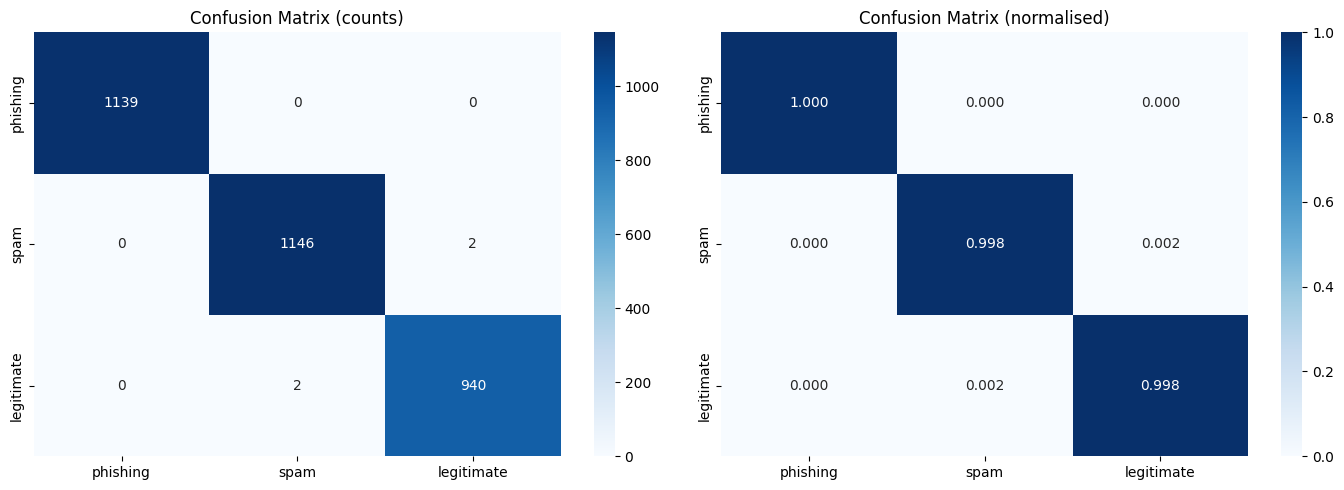

In [13]:
# ── Cell 12: Error analysis + confusion matrix ────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from src.config.training_config import LABEL_NAMES

test_preds = trainer.predict(tok_splits.test)
pred_labels = np.argmax(test_preds.predictions, axis=-1)
true_labels = splits.test["label"].values

error_df = build_error_dataframe(splits.test, test_preds.predictions)
errors   = error_df[~error_df["correct"]]
print(f"Errors: {len(errors)} / {len(error_df)} ({100*len(errors)/len(error_df):.1f}%)")

cm, cm_norm = confusion_matrix_arrays(true_labels, pred_labels)
report_path = save_classification_report(true_labels, pred_labels, OUTPUT_DIR)
print(f"Report saved: {report_path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalised)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

In [14]:
# ── Cell 13: Register model in MLflow Unity Catalog ───────────────────
model_info = register_model(
    run_id=baseline_run_id,
    save_path=save_path,
    model_name=config.mlflow_model_name,
    config=config,
)
print(f"[registry] Registered: {config.mlflow_model_name} v{model_info.registered_model_version}")


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026/05/21 17:29:43 WARNING mlflow.transformers: The model card could not be retrieved from the hub due to Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/kaggle/working/outputs/baseline/best'. Use `repo_type` argument if needed.
2026/05/21 17:29:43 WARNING mlflow.transformers: Unable to find license information for this model. Please verify permissible usage for the model you are storing prior to use.
Registered model 'main.sicurre.phishing-detector' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Created version '4' of model 'main.sicurre.phishing-detector'.


🏃 View run baseline-v20260521 at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874/runs/bd661586391f4b6ea4b80bc2e53e3bd7
🧪 View experiment at: dbc-e645d00b-92eb.cloud.databricks.com/ml/experiments/3653640089754874
[registry] Registered: main.sicurre.phishing-detector v4


In [15]:
# ── Cell 14: Promote if thresholds met ────────────────────────────────
promoted = promote_if_threshold(
    model_name=config.mlflow_model_name,
    test_metrics=test_metrics,
    recall_floor=0.97,
    f1_floor=0.90,
)
print(f"[registry] Promoted to @production: {promoted}")


[registry] Promoted to @production: True


In [16]:
# ── Cell 15: Push to HuggingFace (only if @production) ────────────────
if promoted and state.hf_token:
    hf_url = push_to_hub(
        save_path=save_path,
        hf_repo_id=HF_REPO_ID,
        hf_token=state.hf_token,
        test_metrics=test_metrics,
        mlflow_version=str(model_info.registered_model_version),
        artifact_dir=OUTPUT_DIR,
    )
    print(f"Live: {hf_url}")
else:
    print("Skipped HF push — model did not reach @production threshold.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Live: https://huggingface.co/Mikolinton/sicurre-phishing-fr
